In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline 
import random
import torch 
from d2l import torch as d2l

In [3]:
def synthetic_data(w,b,num_examples):#@save
    
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b
    y+=torch.normal(0,1,y.shape)
    return X,y.reshape((-1,1))#

In [4]:
true_w=torch.tensor([2,-3.4])
true_b=4.2

features,labels=synthetic_data(true_w,true_b,1000)#列向量标签
features.shape
labels.shape

torch.Size([1000, 1])

In [5]:
print('features:',features[0],'\nlabel:',labels[0])



features: tensor([-0.9913,  0.5260]) 
label: tensor([-0.7603])


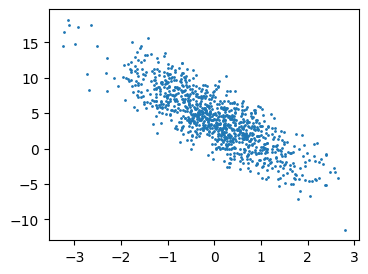

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.scatter(features[:,1].detach().cpu().numpy(), labels.detach().cpu().numpy(), s=1)


In [7]:
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    random.shuffle(indices)
    
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        
        yield features[batch_indices],labels[batch_indices]

In [8]:
batch_size=10

for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[ 0.5893, -0.0691],
        [-0.7934, -1.2854],
        [-0.0505,  0.7285],
        [ 0.4634, -0.2371],
        [-0.5303,  1.2012],
        [-1.0679,  1.3647],
        [-0.0402,  0.4990],
        [-1.1686,  0.1585],
        [ 1.4269,  1.2166],
        [ 0.1943,  0.3502]]) 
 tensor([[ 7.0698],
        [ 8.3597],
        [ 0.3862],
        [ 7.4932],
        [-2.0310],
        [-4.2625],
        [ 2.6117],
        [ 2.7998],
        [ 4.9164],
        [ 2.9066]])


In [9]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

w.shape,b.shape#默认是列向量

(torch.Size([2, 1]), torch.Size([1]))

In [10]:
def linreg(X,w,b):#@save
    return torch.matmul(X,w)+b

def squared_loss(y_hat,y): #@save
    return (y_hat-y.reshape(y_hat.shape))**2/2

def sgd(params,lr,batch_size):#@save
    with torch.no_grad():#临时关闭自动求导
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

In [11]:
lr=0.03
num_epochs=3
net=linreg
loss=squared_loss

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        print(net(X,w,b).shape)
        l=loss(net(X,w,b),y)#y
        l.sum().backward()
        sgd([w,b],lr,batch_size)
        
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch {epoch+1}, loss {float(train_l.mean()):f}')

torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])
torch.Size([10, 1])


线性回归的简洁实现

In [12]:
import numpy as np
import torch 
from torch.utils import data
from d2l import torch as d2l

true_w=torch.tensor([2,-3.4])
true_b=4.3
features,labels=d2l.synthetic_data(true_w,true_b,1000)
features.shape,labels.shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [13]:
def load_array(data_arrays,batch_size,is_train=True):#@save
    
    dataset=data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=is_train)

In [14]:
batch_size=10
data_iter=load_array((features,labels),batch_size)

next(iter(data_iter))

[tensor([[ 0.1972, -0.8395],
         [ 0.4075,  0.0254],
         [-0.8552,  0.3072],
         [ 1.1574, -0.5941],
         [-0.2488,  0.0569],
         [-1.3862, -0.6832],
         [ 0.9248, -1.3579],
         [-0.3864, -0.2142],
         [-0.7854, -1.5419],
         [-0.1737,  2.0822]]),
 tensor([[ 7.5476],
         [ 5.0220],
         [ 1.5516],
         [ 8.6308],
         [ 3.6129],
         [ 3.8298],
         [10.7752],
         [ 4.2552],
         [ 7.9837],
         [-3.1306]])]

3.3.3定义模型

In [ ]:
from torch import nn

net=nn.Sequential()


In [16]:
net[0].weight.data.normal_(0,0.01)
net[0].bias.data.fill_(0)

loss=nn.MSELoss()

trainer=torch.optim.SGD(net.parameters(),lr=0.03)

In [ ]:
num_epochs=3

for epoch in range(num_epochs):
    for X,y in data_iter:
        l=loss(net(X),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l=loss(net(features),labels)
    print(f' epoch {epoch+1}, loss {l:f}')

 epoch 1, loss 0.000095
 epoch 2, loss 0.000094
 epoch 3, loss 0.000094


In [ ]:
w=net[0].weight.data
print('w的估计误差:',true_w-w.reshape(true_w.shape))
b=net[0].bias.data
print('b的估计误差:',true_b-b)

w的估计误差: tensor([1.6952e-04, 3.0756e-05])
b的估计误差: tensor([0.0002])


In [1]:
%matplotlib inline
import torch 
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

In [ ]:
trans=transforms.ToTensor()#将图像数据转变为32位的浮点的形式

mnist_train=torchvision.datasets.FashionMNIST(root='../data',train=True,transform=trans,download=True)

mnist_test=torchvision.datasets.FashionMNIST(root='../data',train=False,transform=trans,download=True)

len(mnist_train),len(mnist_test)

100%|██████████| 26421880/26421880 [19:48<00:00, 22238.84it/s]


Extracting ../data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 71076.63it/s]


Extracting ../data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [03:29<00:00, 21091.57it/s]


Extracting ../data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<?, ?it/s]

Extracting ../data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



(60000, 10000)

: 